
📊 Image Count with Ratios:
    split                  class  count  total_count  ratio (%)
0    test  Bacterial leaf blight     64         1427       4.48
1    test                healthy     67         1432       4.68
2    test             Brown spot     66         1430       4.62
3    test              Leaf smut     65         1429       4.55
4   train  Bacterial leaf blight   1300         1427      91.10
5   train                healthy   1300         1432      90.78
6   train             Brown spot   1300         1430      90.91
7   train              Leaf smut   1300         1429      90.97
8     val  Bacterial leaf blight     63         1427       4.41
9     val                healthy     65         1432       4.54
10    val             Brown spot     64         1430       4.48
11    val              Leaf smut     64         1429       4.48


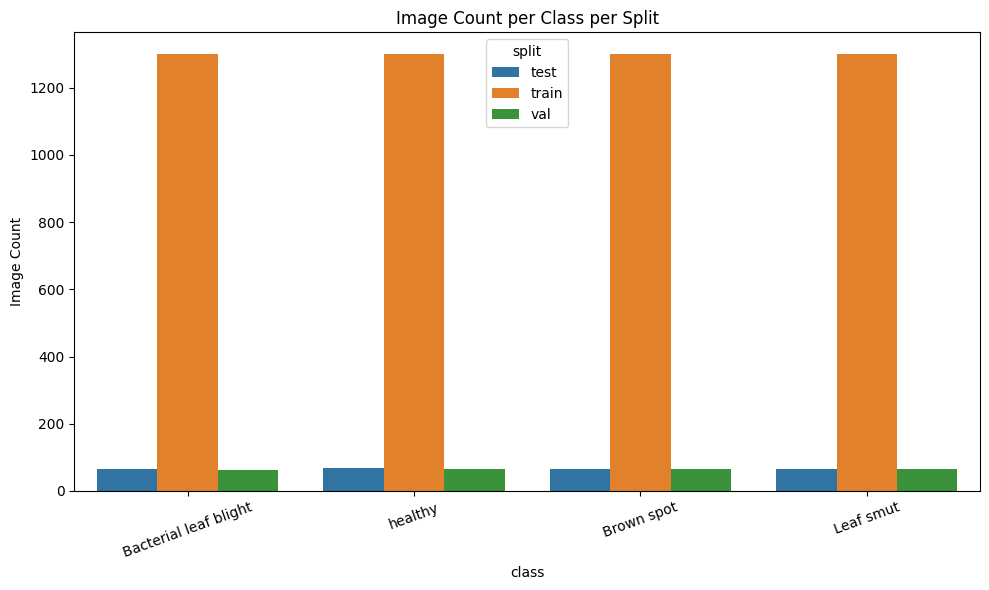

In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import pandas as pd
import random

# 📁 Base directory
base_dir = r"C:\Users\noorul\Desktop\another appproach\dataset"

# 🗂️ Expected splits and classes
splits = ['test','train', 'val']
classes = [ 'Bacterial leaf blight', 'healthy', 'Brown spot', "Leaf smut"]

# 📊 Data collection
data = []

for split in splits:
    for cls in classes:
        folder = os.path.join(base_dir, split, cls)
        if os.path.exists(folder):
            count = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        else:
            count = 0
        data.append({'split': split, 'class': cls, 'count': count})

# 📈 Create DataFrame
df = pd.DataFrame(data)

# 🔍 Show total per class
total_counts = df.groupby('class')['count'].sum().reset_index().rename(columns={'count': 'total_count'})

# 🎯 Ratio per split
df = df.merge(total_counts, on='class')
df['ratio (%)'] = round((df['count'] / df['total_count']) * 100, 2)

print("\n📊 Image Count with Ratios:")
print(df)

# 📉 Bar plot for counts
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='class', y='count', hue='split')
plt.title('Image Count per Class per Split')
plt.xticks(rotation=20)
plt.ylabel('Image Count')
plt.tight_layout()
plt.show()


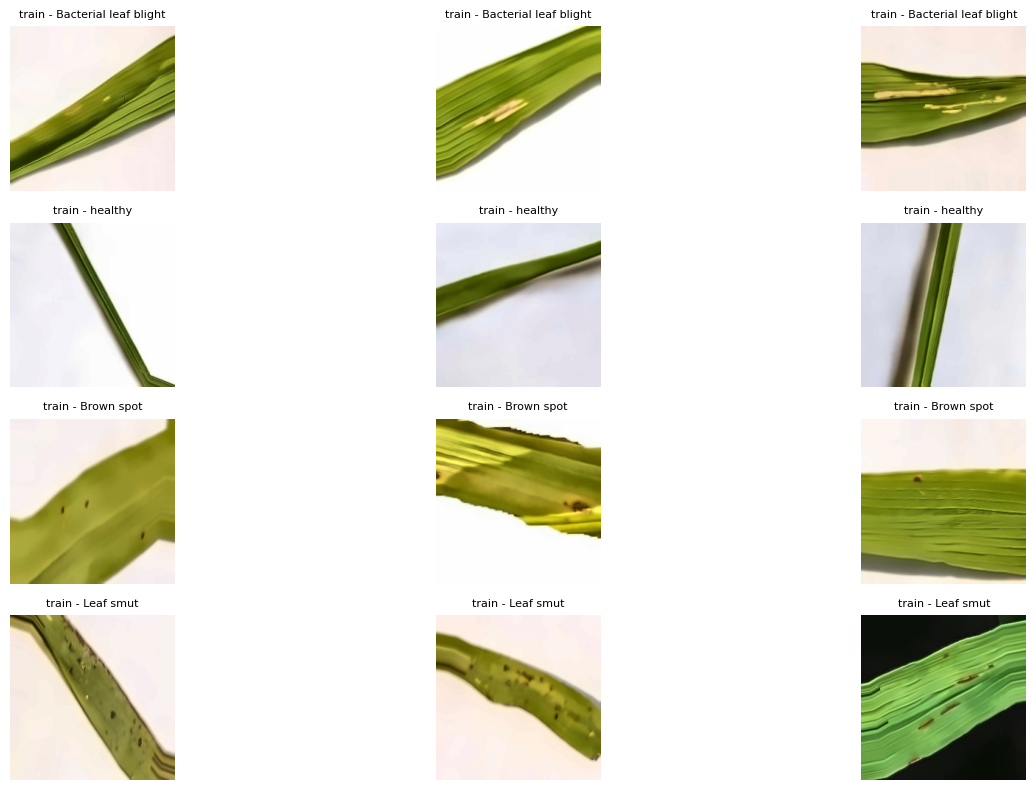

In [2]:
def show_random_images(base_dir, split, classes, num_per_class=3):
    plt.figure(figsize=(15, 8))
    img_idx = 1
    for cls in classes:
        folder = os.path.join(base_dir, split, cls)
        if not os.path.exists(folder):
            continue
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        samples = random.sample(files, min(num_per_class, len(files)))

        for file in samples:
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(classes), num_per_class, img_idx)
            plt.imshow(img)
            plt.title(f"{split} - {cls}", fontsize=8)
            plt.axis('off')
            img_idx += 1
    plt.tight_layout()
    plt.show()

# 🖼️ Example usage: show 3 random images per class in the train set
show_random_images(base_dir, split='train', classes=classes, num_per_class=3)


🔍 Analyzing dataset at: C:\Users\noorul\Desktop\another appproach\dataset\train


Checking Leaf smut: 100%|██████████| 1300/1300 [00:09<00:00, 143.03it/s]


📊 Image count per class:
  Bacterial leaf blight: 1300 images
  Brown spot: 1300 images
  healthy: 1300 images
  Leaf smut: 1300 images

🧯 Total corrupted images found: 0

🖼️ Unique image shapes: {(224, 224, 3)}



C:\Users\noorul\AppData\Local\Temp\ipykernel_22392\4039642698.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='Set2')


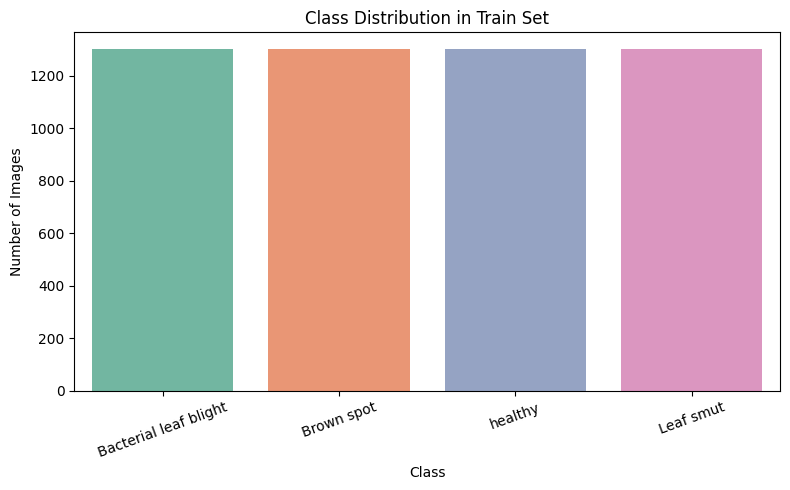

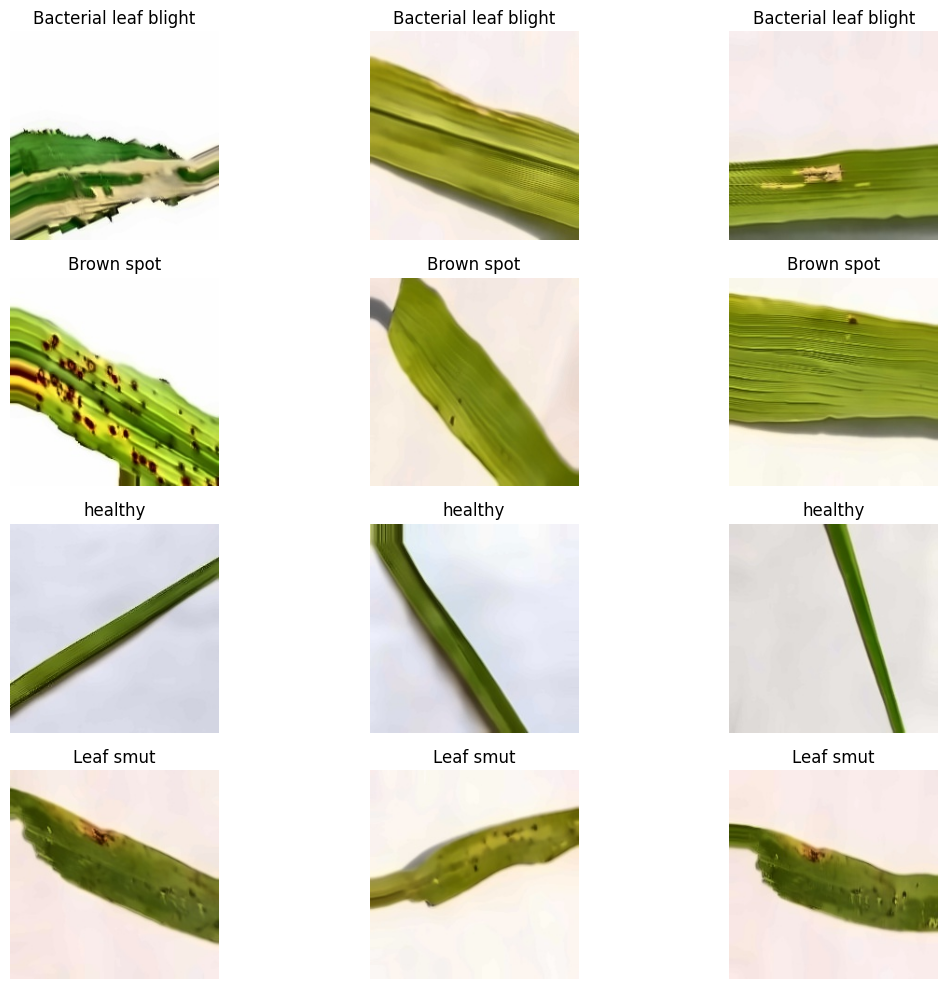

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict
from tqdm import tqdm

# Set paths
dataset_path = r"C:\Users\noorul\Desktop\another appproach\dataset\train"  # change to val or test as needed

# Initialize
class_counts = defaultdict(int)
image_shapes = []
corrupted_images = []
all_classes = os.listdir(dataset_path)

print("🔍 Analyzing dataset at:", dataset_path)

# Scan through dataset
for class_name in all_classes:
    class_path = os.path.join(dataset_path, class_name)
    for img_name in tqdm(os.listdir(class_path), desc=f"Checking {class_name}"):
        img_path = os.path.join(class_path, img_name)

        # Load image
        try:
            img = cv2.imread(img_path)
            if img is None:
                corrupted_images.append(img_path)
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            image_shapes.append(img.shape)
            class_counts[class_name] += 1
        except:
            corrupted_images.append(img_path)

# Print results
print("\n📊 Image count per class:")
for k, v in class_counts.items():
    print(f"  {k}: {v} images")

print(f"\n🧯 Total corrupted images found: {len(corrupted_images)}")
if corrupted_images:
    print("  Sample corrupted image path:", corrupted_images[0])

# Check image shape consistency
unique_shapes = set(image_shapes)
print("\n🖼️ Unique image shapes:", unique_shapes)

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='Set2')
plt.title("Class Distribution in Train Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Show random images from each class
def show_sample_images(dataset_path, class_names, num_images=3):
    plt.figure(figsize=(12, len(class_names) * 2.5))
    i = 1
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        images = os.listdir(class_path)
        sample_imgs = np.random.choice(images, num_images, replace=False)
        for img_name in sample_imgs:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(len(class_names), num_images, i)
            plt.imshow(img)
            plt.axis("off")
            plt.title(class_name)
            i += 1
    plt.tight_layout()
    plt.show()

# Show random 3 images from each class
show_sample_images(dataset_path, all_classes, num_images=3)
